# Week 4 - Function 1 ((13DP, 2D))

# Setup
Let's load all the imports in the top to avoid repeating and simplify the readability of each solution.

In [13]:
import warnings
import numpy as np

from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
from sklearn.svm import SVC, SVR

from utils.plotting_utils import (
    plot_2D_mean_uncertainty,
    plot_bar_diff,
    plot_log_transform,
    plot_svm_analysis,
    plot_acquisition_comparison,
)

# Plan
We now have ((13, 2)) — 13 data points, 2D input — found at `./data/week_4/function_1/`.

1. Load data
2. Preprocessing (QuantileTransformer + log10, unchanged from week 3)
3. Build probabilistic Models — **new**: convergence guard excludes GP(y_qt) from ensemble if it hits a `length_scale` bound
4. SVM Analysis — **two fixes vs week 3**: softer margin (C: 10→1) + broader promising threshold (−50→−100)
5. Acquisition Function — **three fixes vs week 3**: SVM fail-safe + SVR clamping + GP(y_qt) convergence guard

# 1. Load data

The 13th point (submitted at the end of week 3) landed close to existing points and did not improve the best known output by much. The data distribution is largely unchanged, so this week we focus entirely on fixing modelling issues identified after the week 3 run.

In [14]:
X_train_raw = np.load(r"./data/week_4/function_1/inputs.npy")
y_train_raw = np.load(r"./data/week_4/function_1/outputs.npy")

print(f"Shape: X={X_train_raw.shape}, y={y_train_raw.shape}")
print(f"X range: [{X_train_raw.min():.4f}, {X_train_raw.max():.4f}]")
print(f"y range: [{y_train_raw.min():.2e}, {y_train_raw.max():.2e}]")

Shape: X=(13, 2), y=(13,)
X range: [0.0787, 0.8839]
y range: [-3.61e-03, 5.62e-06]


# 2. Preprocessing

Outputs span a massive range — most are negative (penalty zone), with the best positive value at ~5.6×10⁻⁶. `StandardScaler` collapses this structure because a single large negative outlier dominates the variance, making all other differences look like noise.

Two complementary transformations are used (established in week 3, unchanged here):
- **QuantileTransformer** (all 13 points): Rank-based [0, 1] scaling that preserves ordering without being skewed by the outlier.
- **log10 transform** (positive points only): Exposes the gradient among the best points. Maximising log10(y) is equivalent to maximising y, so this is a valid surrogate target.

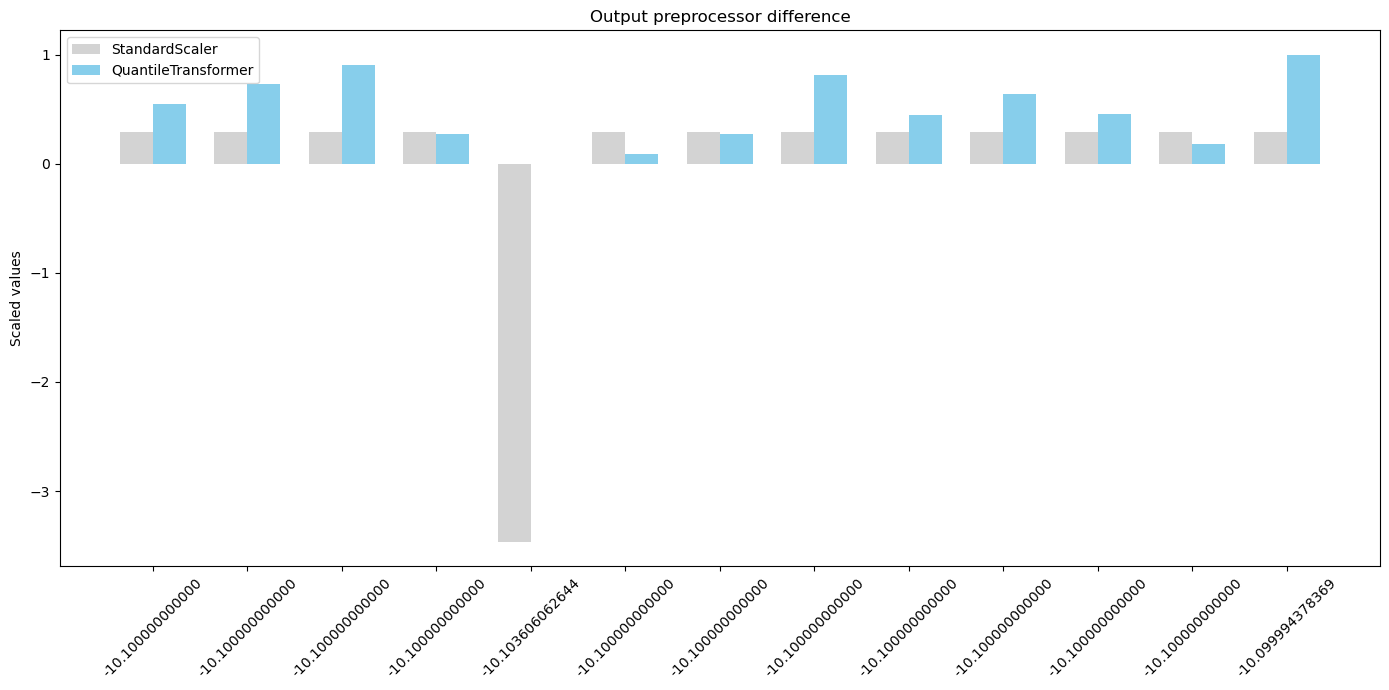

Total points: 13

Range for new normalized output: [0.0, 1.0]

Best point: X=[0.483198 0.47931 ], y=5.62e-06, QuantileTransformer(y)=1.0


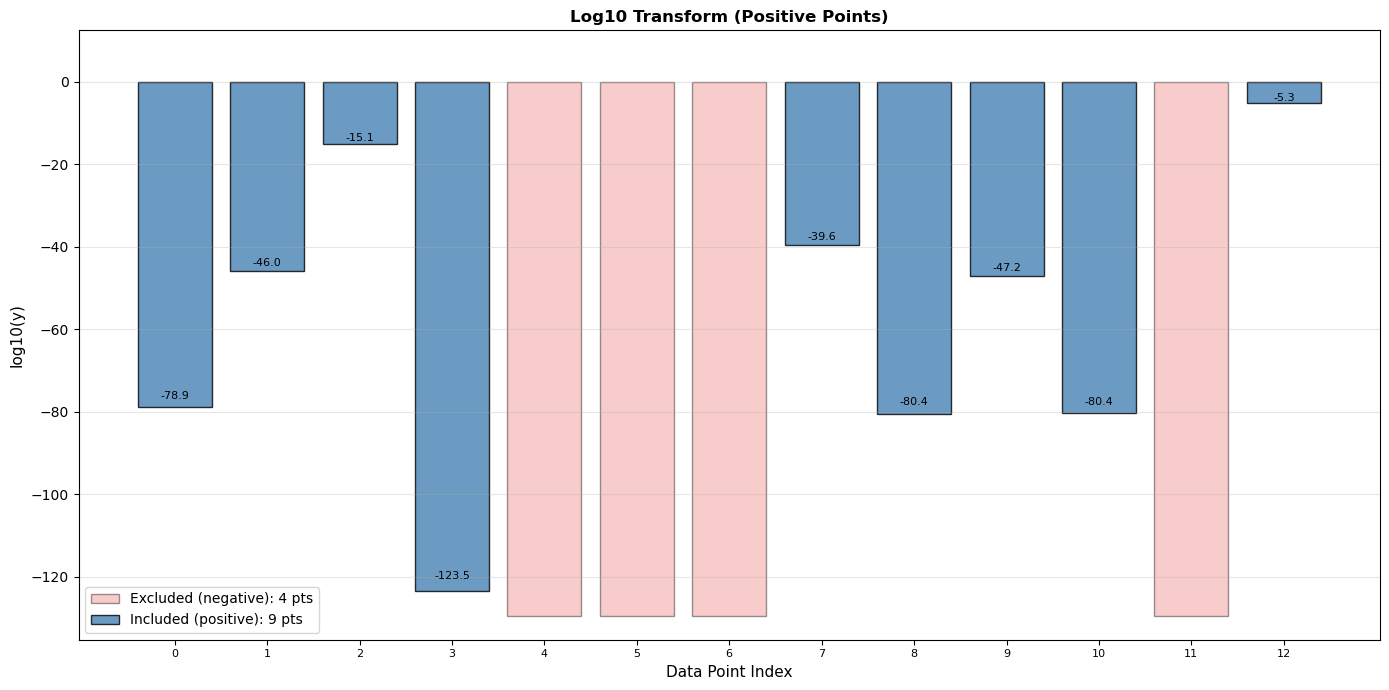

In [15]:
scaler_X = MinMaxScaler()
X_train = scaler_X.fit_transform(X_train_raw)

scaler_ss = StandardScaler()
y_ss = scaler_ss.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

scaler_qt = QuantileTransformer(n_quantiles=len(y_train_raw)-1, output_distribution='uniform')
y_qt = scaler_qt.fit_transform(y_train_raw.reshape(-1, 1)).ravel()

plot_bar_diff(y_train_raw, y_ss, y_qt, 'StandardScaler', 'QuantileTransformer', 'Scaled values', 'Output preprocessor difference')

print(f"Total points: {len(X_train)}")
print(f"\nRange for new normalized output: [{y_qt.min():.1f}, {y_qt.max():.1f}]")
print(f"\nBest point: X={X_train_raw[np.argmax(y_train_raw)]}, y={y_train_raw.max():.2e}, QuantileTransformer(y)={y_qt.max():.1f}")

## Another option is to log10 for positive only
# Log-space transformation: outputs span ~120 orders of magnitude (1e-124 to 1e-16).
# StandardScaler collapses all this structure into "zero" vs the single outlier.
# In log-space, the GP can actually distinguish the gradient toward the peak.
pos_mask = y_train_raw > 0
X_train_pos = X_train[pos_mask]

# For the GP: use only positive points in log-space (maximizing log10(y) = maximizing y)
y_log_pos = np.log10(y_train_raw[pos_mask])

plot_log_transform(y_train_raw, y_log_pos, pos_mask)

# 3. Build probabilistic Models

Two GP models with different preprocessing strategies (unchanged from week 3):
- **gp_qt** (QuantileTransformer, all 13 points): `length_scale` floored at 0.2 to force smooth interpolation — QuantileTransformer destroys the natural spatial gradient, so without a floor the GP collapses to tiny spikes at each training point.
- **gp_log** (log10, positive points only): Preserves the gradient in log-space. The GP learns spatial structure directly where it is most visible.

Both use `nu=2.5` (smooth Matérn), `alpha=0.01` / `1e-4` as observation noise, and 30–50 random restarts to avoid local optima in the marginal likelihood.

**New in week 4 — convergence guard for gp_qt**: The GP fitting is wrapped in a warning catcher. If gp_qt hits its `length_scale` bound (a `ConvergenceWarning`), the flag `gp_qt_converged = False` is set and gp_qt is excluded from the acquisition ensemble in section 5. A non-converged gp_qt is fitting from a constrained, non-optimal kernel and can dominate the ensemble with unreliable predictions.

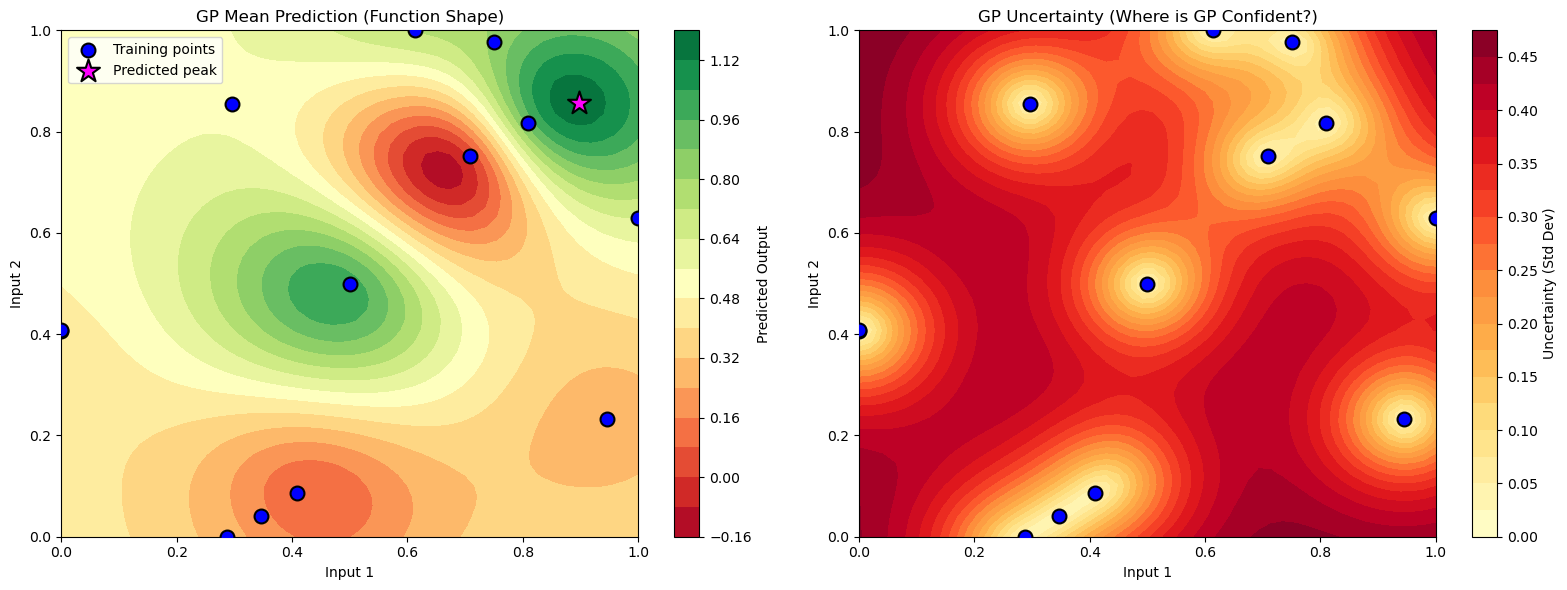

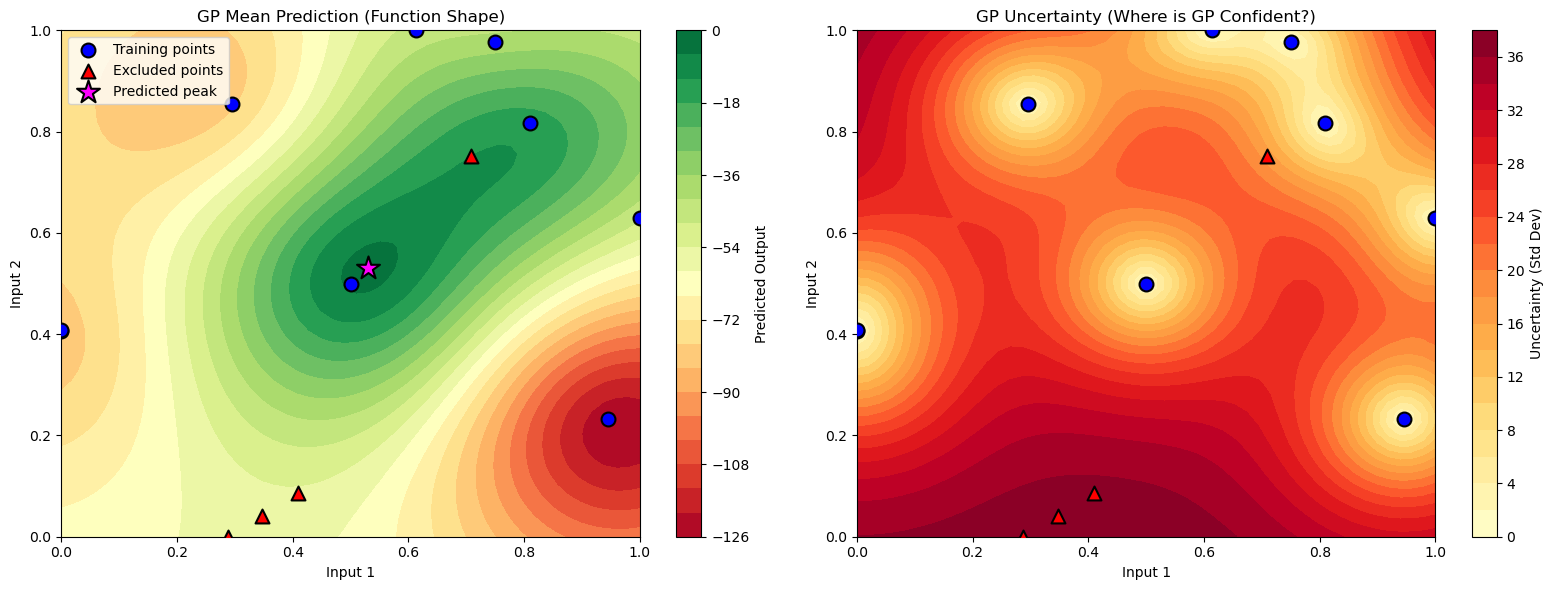

In [16]:
# GP on QuantileTransformer output (all points)
# - QuantileTransformer maps to [0, 1] uniform — already normalized
# - Force length_scale >= 0.2 to prevent overfitting (QT destroys spatial gradient,
#   so without a floor the GP collapses to tiny spikes at each point)
# - alpha=0.01: treat QT values as slightly noisy to encourage smooth interpolation
gp_qt = GaussianProcessRegressor(
    kernel=ConstantKernel(0.25, (1e-3, 10)) * Matern(
        length_scale=0.5,
        nu=2.5,
        length_scale_bounds=(0.2, 5.0)
    ),
    alpha=0.01,
    normalize_y=True,
    n_restarts_optimizer=30,
    optimizer='fmin_l_bfgs_b'
)

# GP in log-space on positive points only
# - Trains on log10(y) where the range is [-123.5, -5.3]
# - normalize_y=True here because log-space has large range
gp_log = GaussianProcessRegressor(
    kernel=ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=0.3,
        nu=2.5,
        length_scale_bounds=(1e-3, 10.0)
    ),
    alpha=1e-4,
    normalize_y=True,
    n_restarts_optimizer=50
)

# Fit gp_qt and detect if the optimiser hits a bound (ConvergenceWarning).
# QT destroys the spatial gradient, so the GP may want a length_scale shorter than
# the 0.2 floor — if so, the fit is not at a true marginal-likelihood optimum and
# gp_qt should be excluded from the acquisition ensemble.
with warnings.catch_warnings(record=True) as _w:
    warnings.simplefilter("always")
    gp_qt.fit(X_train, y_qt)
    gp_qt_converged = not any(issubclass(x.category, ConvergenceWarning) for x in _w)

if not gp_qt_converged:
    print("WARNING: GP(y_qt) hit a length_scale bound — will be excluded from the acquisition ensemble.")
else:
    print("GP(y_qt) converged normally.")

gp_log.fit(X_train_pos, y_log_pos)

# Negative-output points (excluded from GP, shown for context)
X_train_neg = X_train[~pos_mask]

# Create prediction grid
# X_train is MinMaxScaled to [0, 1], so the grid spans the full range directly
n_grid = 50
x1_range = np.linspace(0, 1, n_grid)
x2_range = np.linspace(0, 1, n_grid)

X1_test, X2_test = np.meshgrid(x1_range, x2_range)
X_grid = np.c_[X1_test.ravel(), X2_test.ravel()]

# Make predictions
mu_gp_qt, sigma_gp_qt = gp_qt.predict(X_grid, return_std=True)
mu_gp_log, sigma_gp_log = gp_log.predict(X_grid, return_std=True)

plot_2D_mean_uncertainty(
   X_train,
   X1_test,
   X2_test,
   mu_gp_qt,
   sigma_gp_qt,
   X_excluded=None,
)

plot_2D_mean_uncertainty(
   X_train_pos,
   X1_test,
   X2_test,
   mu_gp_log,
   sigma_gp_log,
   X_excluded=X_train_neg,
)

# 4. SVM Analysis

The GPs treat every region of the search space equally when computing uncertainty. Several points produce strongly negative outputs (a penalty zone), so we use an SVM classifier to learn the boundary between promising and unpromising regions — its P(promising) acts as a soft mask on the acquisition function.

Three SVM models complement the GPs:
1. **SVM Classifier** — two fixes applied vs week 3:
   - **C: 10 → 1** (softer margin): With only ~5 positive points in [0, 1]², `C=10` caused the decision boundary to collapse to a tiny island around the support vectors, classifying 0% of the grid as promising and silencing the entire acquisition surface.
   - **Threshold: −50 → −100**: The −50 cutoff on log10(y) was too selective, keeping only 5 of the positive points in the "promising" class. Lowering to −100 captures more positive points, reducing class imbalance.
2. **SVR Surrogate (log-space)**: Trained on positive points with log10(y) — independent surrogate to cross-validate gp_log.
3. **SVR Surrogate (QuantileTransformer)**: Trained on all points with y_qt — independent surrogate to cross-validate gp_qt.

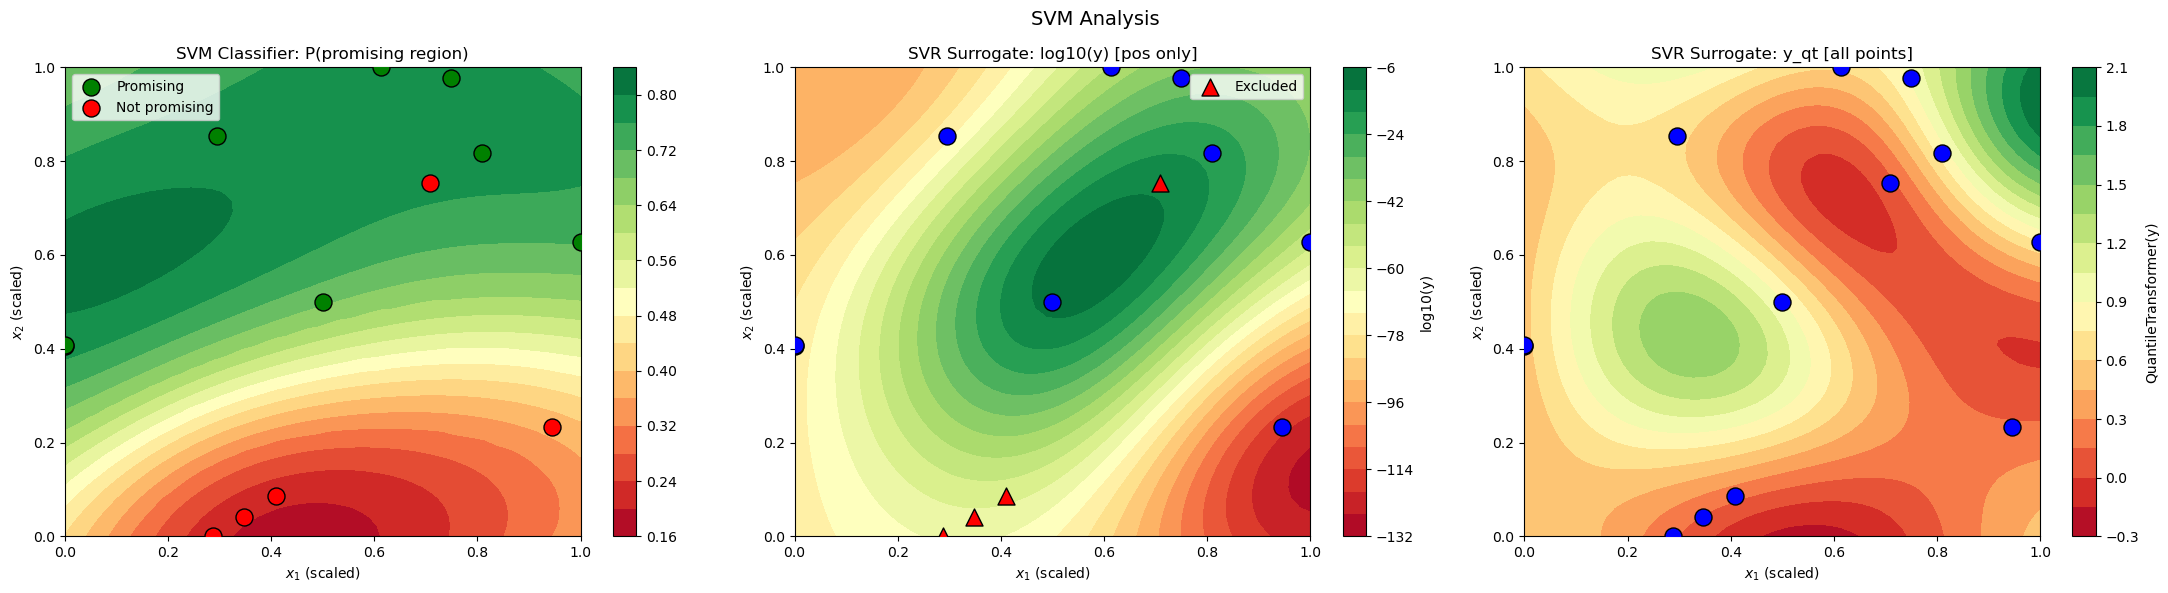


SVR (log-space, pos only) suggests peak near: [0.5404, 0.5529]
  Predicted log10(y): -7.6

SVR (QuantileTransformer, all pts) suggests peak near: [0.8839, 0.8308]
  Predicted y_qt: 2.082

SVM Classifier:
  Promising labels: [1 1 1 0 0 0 0 1 1 1 1 0 1] (1=promising)
  Grid area classified as promising (P>0.5): 68.1%


In [17]:
# --- 2a. SVM Classifier: promising vs not-promising regions ---
# Label points as "promising" if positive AND log10(y) > -100 (broader than -50 to
# avoid over-selective labelling when only a few points have strong positive signal)
# Fix D: threshold raised from -50 → -100 to capture more positive points.
# Fix B: C reduced from 10 → 1 (softer margin) to prevent SVM from collapsing
#        to an infinitesimally small island around the support vectors.
svm_labels = np.zeros(len(y_train_raw), dtype=int)
for i, yi in enumerate(y_log_pos):
    if yi > -100:
        svm_labels[np.where(pos_mask)[0][i]] = 1

svm_clf = SVC(kernel='rbf', C=1, gamma='scale', probability=True)
svm_clf.fit(X_train, svm_labels)

# Predict promising probability on the grid
svm_proba = svm_clf.predict_proba(X_grid)[:, 1]

# --- 2b. SVR Surrogate in log-space (positive points only) ---
svr_log = SVR(kernel='rbf', C=100, gamma='scale', epsilon=5.0)
svr_log.fit(X_train_pos, y_log_pos)
mu_svr_log = svr_log.predict(X_grid)

# --- 2c. SVR Surrogate on QuantileTransformer output (all points) ---
svr_qt = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_qt.fit(X_train, y_qt)
mu_svr_qt = svr_qt.predict(X_grid)

# --- Plot all three ---
plot_svm_analysis(X1_test, X2_test, svm_proba, mu_svr_log, mu_svr_qt,
                  X_train, X_train_pos, X_train_neg, svm_labels)

# SVR best predictions
best_svr_log_idx = np.argmax(mu_svr_log)
best_svr_log_point = scaler_X.inverse_transform([X_grid[best_svr_log_idx]])[0]
best_svr_qt_idx = np.argmax(mu_svr_qt)
best_svr_qt_point = scaler_X.inverse_transform([X_grid[best_svr_qt_idx]])[0]

print(f"\nSVR (log-space, pos only) suggests peak near: [{best_svr_log_point[0]:.4f}, {best_svr_log_point[1]:.4f}]")
print(f"  Predicted log10(y): {mu_svr_log[best_svr_log_idx]:.1f}")
print(f"\nSVR (QuantileTransformer, all pts) suggests peak near: [{best_svr_qt_point[0]:.4f}, {best_svr_qt_point[1]:.4f}]")
print(f"  Predicted y_qt: {mu_svr_qt[best_svr_qt_idx]:.3f}")

# Promising region stats
print(f"\nSVM Classifier:")
print(f"  Promising labels: {svm_labels} (1=promising)")
print(f"  Grid area classified as promising (P>0.5): {(svm_proba > 0.5).mean()*100:.1f}%")

# 5. Acquisition Function (SVM-constrained UCB)

**Inherited from week 3** (rationale summarised for context):
- **UCB (kappa=5)**: Balances exploitation of the predicted peak with broad exploration of uncertain regions. Expected Improvement was dropped in week 3 because it concentrates too narrowly around the current best when outputs span many orders of magnitude.
- **SVM constraint**: UCB × P(promising) steers evaluations away from the negative-output penalty zone.
- **4-surrogate ensemble**: GP(y_qt), GP(y_log_pos), SVR(y_log_pos), SVR(y_qt) — averaging normalised constrained scores hedges against any single model being wrong with so few data points.

**New in week 4:**
- **Fix A — SVM fail-safe**: If the SVM classifies < 5% of the grid as promising (i.e. the decision boundary has collapsed), fall back to uniform weights so the constraint does not silence the entire acquisition surface.
- **Fix C — SVR clamping**: SVR predictions are clipped to the training range before entering the ensemble. In week 3, SVR(y_qt) was extrapolating above 1.0 (the QuantileTransformer maximum), causing it to dominate the ensemble with inflated scores at the data boundary.
- **Fix E — GP(y_qt) convergence guard**: GP(y_qt) is excluded from the ensemble if it raised a `ConvergenceWarning` during fitting (i.e. the optimiser hit the `length_scale` lower bound). A constrained, non-converged GP extrapolates from a poorly-fitted kernel and can pull the ensemble recommendation toward the boundary of the training data, overriding the three more reliable surrogates.

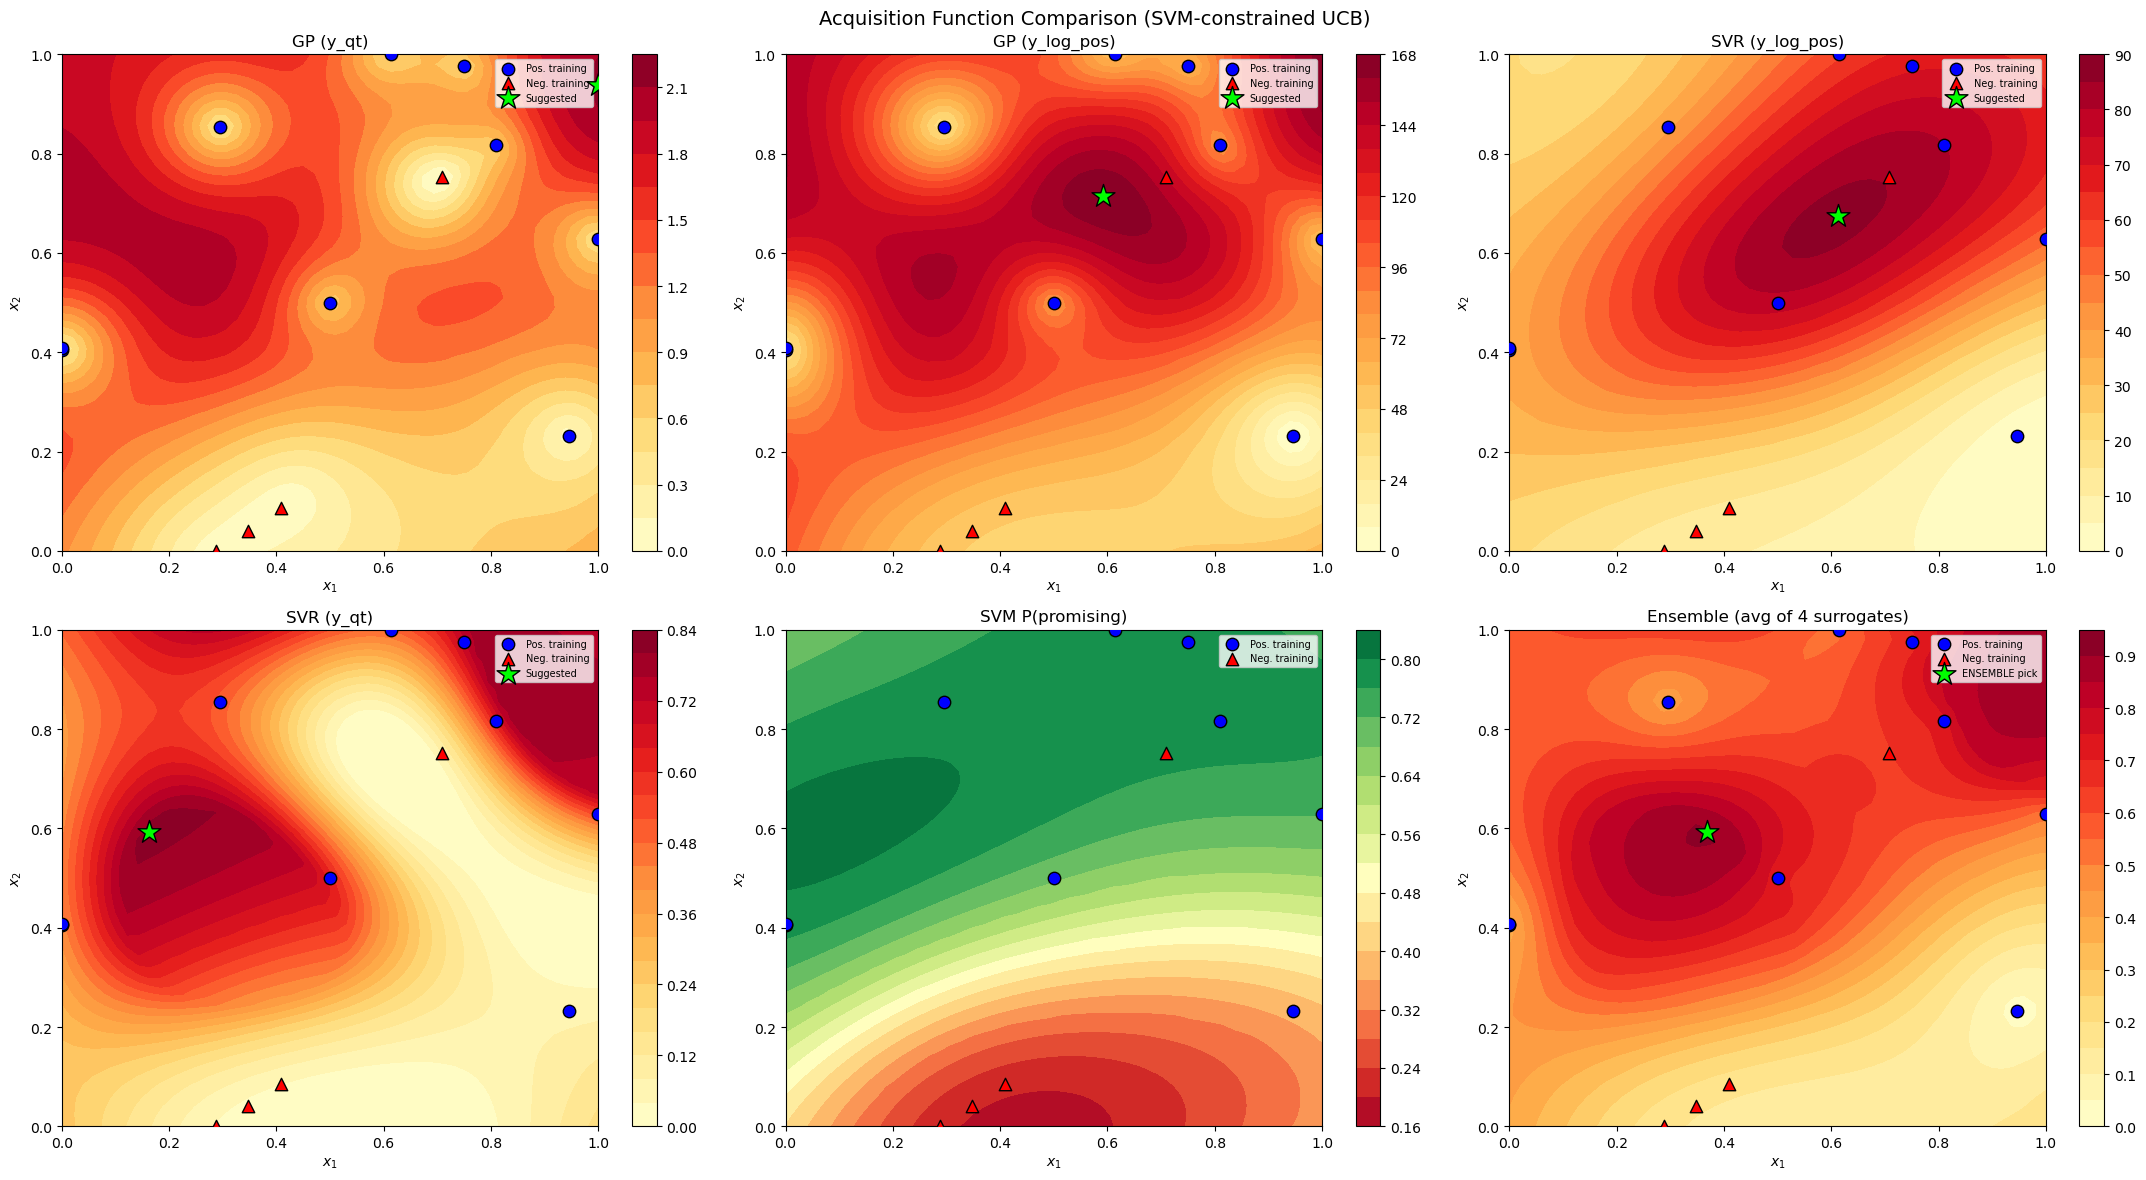


RECOMMENDED NEXT POINT (Ensemble of 3 surrogates)
  Ensemble members: GP (y_log_pos), SVR (y_log_pos), SVR (y_qt)
  GP (y_qt) status: EXCLUDED (did not converge)

  Input (original space): [0.376893, 0.552888]
  Input (scaled):         [0.367347, 0.591837]
  SVM P(promising):       0.777

  Individual surrogate suggestions (own best point):
    GP (y_qt)           : [0.883890, 0.830847]  SVM P=0.760  ✗ excluded
    GP (y_log_pos)      : [0.556795, 0.650991]  SVM P=0.772  ✓
    SVR (y_log_pos)     : [0.573150, 0.618290]  SVM P=0.759  ✓
    SVR (y_qt)          : [0.213345, 0.552888]  SVM P=0.809  ✓

  Score of each surrogate AT the ensemble-recommended point
  (100% = that surrogate's own best; lower = away from its individual peak):
    GP (y_log_pos)      :  89.2%  (own best is at [0.557, 0.651])
    SVR (y_log_pos)     :  86.4%  (own best is at [0.573, 0.618])
    SVR (y_qt)          :  96.1%  (own best is at [0.213, 0.553])

  Current best: [0.483198, 0.479310] (log10(y) = -5.3)

  

In [18]:
def upper_confidence_bound(mu, sigma, kappa=2.0):
    """
    Upper Confidence Bound (UCB) acquisition function.
    UCB = mean + kappa * std
    """
    return mu + kappa * sigma


# --- Compute UCB for all surrogates ---
kappa = 5.0

ucb_gp_qt  = upper_confidence_bound(mu_gp_qt,  sigma_gp_qt,  kappa=kappa)
ucb_gp_log = upper_confidence_bound(mu_gp_log, sigma_gp_log, kappa=kappa)

# Fix C: Clamp SVR predictions to valid range to prevent out-of-bounds extrapolation.
# SVR(y_qt) can predict above 1.0 (QT max) at the data boundary; clamp to [0, 1].
# SVR(y_log_pos) can predict below the training minimum; clamp to observed range.
pred_svr_log = np.clip(mu_svr_log, y_log_pos.min(), y_log_pos.max())
pred_svr_qt  = np.clip(mu_svr_qt,  0.0, 1.0)

# Fix A: SVM fail-safe — if SVM collapses to classify <5% of the grid as promising,
# the constraint silences the entire acquisition surface. Fall back to uniform weights.
if (svm_proba > 0.5).mean() < 0.05:
    print("WARNING: SVM classified <5% of grid as promising — applying fail-safe (uniform weights).")
    svm_proba_effective = np.ones_like(svm_proba)
else:
    svm_proba_effective = svm_proba

# --- SVM-constrained UCB for each surrogate ---
def constrained_ucb(ucb_vals, svm_proba):
    """Shift UCB positive, multiply by SVM constraint."""
    ucb_shifted = ucb_vals - ucb_vals.min() + 1e-6
    return ucb_shifted * svm_proba

ucb_c_gp_qt   = constrained_ucb(ucb_gp_qt,   svm_proba_effective)
ucb_c_gp_log  = constrained_ucb(ucb_gp_log,  svm_proba_effective)
ucb_c_svr_log = constrained_ucb(pred_svr_log, svm_proba_effective)
ucb_c_svr_qt  = constrained_ucb(pred_svr_qt,  svm_proba_effective)

# --- Find best point per surrogate ---
surrogates = {
    'GP (y_qt)':     ucb_c_gp_qt,
    'GP (y_log_pos)': ucb_c_gp_log,
    'SVR (y_log_pos)': ucb_c_svr_log,
    'SVR (y_qt)':    ucb_c_svr_qt,
}

best_points = {}
for name, ucb_vals in surrogates.items():
    idx = np.argmax(ucb_vals)
    best_points[name] = {
        'idx': idx,
        'norm': X_grid[idx],
        'orig': scaler_X.inverse_transform([X_grid[idx]])[0],
        'svm_p': svm_proba[idx],
    }

# --- Ensemble: average normalized constrained UCBs ---
# GP(y_qt) is excluded if it did not converge (hit a length_scale bound).
# QT destroys the spatial gradient, so a non-converged GP(y_qt) is extrapolating
# from a poorly-fitted kernel and would dominate the ensemble unfairly.
def normalize_01(arr):
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-10)

norm_ucb = {name: normalize_01(ucb_vals) for name, ucb_vals in surrogates.items()}

ensemble_members = ['GP (y_log_pos)', 'SVR (y_log_pos)', 'SVR (y_qt)']
if gp_qt_converged:
    ensemble_members.append('GP (y_qt)')

ensemble_ucb = sum(norm_ucb[m] for m in ensemble_members) / len(ensemble_members)

best_ensemble_idx = np.argmax(ensemble_ucb)
x_next_norm = X_grid[best_ensemble_idx]
x_next_orig = scaler_X.inverse_transform([x_next_norm])[0]

# --- Plot surrogates + ensemble ---
plot_acquisition_comparison(X1_test, X2_test, surrogates, svm_proba,
                            ensemble_ucb, X_train_pos, X_train_neg,
                            best_points, x_next_norm)

# --- Summary ---
n_ensemble = len(ensemble_members)
gp_qt_status = "included" if gp_qt_converged else "EXCLUDED (did not converge)"

print(f"\n{'='*80}")
print(f"RECOMMENDED NEXT POINT (Ensemble of {n_ensemble} surrogates)")
print(f"{'='*80}")
print(f"  Ensemble members: {', '.join(ensemble_members)}")
print(f"  GP (y_qt) status: {gp_qt_status}")
print(f"\n  Input (original space): [{x_next_orig[0]:.6f}, {x_next_orig[1]:.6f}]")
print(f"  Input (scaled):         [{x_next_norm[0]:.6f}, {x_next_norm[1]:.6f}]")
print(f"  SVM P(promising):       {svm_proba[best_ensemble_idx]:.3f}")

print(f"\n  Individual surrogate suggestions (own best point):")
for name, bp in best_points.items():
    in_ens = "✓" if name in ensemble_members else "✗ excluded"
    print(f"    {name:20s}: [{bp['orig'][0]:.6f}, {bp['orig'][1]:.6f}]  SVM P={bp['svm_p']:.3f}  {in_ens}")

# Score breakdown — explains WHY the ensemble chose this point over each surrogate's own best.
# The ensemble picks the point with the highest AVERAGE normalised score across all members;
# this is often a compromise that none of the surrogates ranked first individually.
print(f"\n  Score of each surrogate AT the ensemble-recommended point")
print(f"  (100% = that surrogate's own best; lower = away from its individual peak):")
for name in ensemble_members:
    score_at_rec = norm_ucb[name][best_ensemble_idx]
    score_at_own = norm_ucb[name][best_points[name]['idx']]  # always 1.0 by definition
    print(f"    {name:20s}: {score_at_rec*100:5.1f}%  (own best is at [{best_points[name]['orig'][0]:.3f}, {best_points[name]['orig'][1]:.3f}])")

print(f"\n  Current best: [{X_train_raw[np.argmax(y_train_raw)][0]:.6f}, {X_train_raw[np.argmax(y_train_raw)][1]:.6f}] (log10(y) = {np.log10(y_train_raw.max()):.1f})")
print(f"\n  SVM grid coverage: {(svm_proba > 0.5).mean()*100:.1f}% promising (fail-safe threshold: 5%)")
print(f"  SVM effective weights: {'uniform (fail-safe)' if (svm_proba > 0.5).mean() < 0.05 else 'SVM P(promising)'}")